# Contents
> 00. **Imports**: Standard libraries for data processing and geospatial analysis.
> 01. **Merge Roads and Bridges Data:** Loads raw road and bridge data, normalises strings, computes segment lengths from chainage, aggregates bridge condition per LRP, filters to N and R roads, and exports the processed GeoDataFrame.
> 02. **Prepare Criticality:** Loads RMMS traffic data from all `.traffic.htm` files, computes a freight-weighted criticality score per segment, and assigns each LRP to its corresponding road segment via a chainage range join.
> 03. **Prepare Vulnerability:** Loads flood and earthquake shapefiles, performs spatial joins to assign hazard values to each LRP, and computes a final vulnerability score combining bridge condition and maximum environmental hazard.
> 04. **Visualise Vulnerability and Criticality:** Side-by-side geographical maps of bridge vulnerability and road criticality across the network.
> 05. **Data Analysis on Vulnerability:** Top-10 most vulnerable bridges and roads, with distribution plots and discussion of the rank order.
> 06. **Data Analysis on Criticality:** Top-10 most critical road segments and roads, with distribution plots and discussion of the rank order.

---
# 00 Imports

In [1]:
import pandas as pd
import os
import numpy as np
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

---
# 01 Merge Roads and Bridges Data

In [2]:
raw_df      = pd.read_csv("../data/_roads3.csv")
bridge_info = pd.read_excel("../data/BMMS_overview.xlsx")

df = raw_df.copy()
df["id"] = range(len(df))

# length from km to m
df["length"] = (
    df.groupby("road")["chainage"]
    .diff().abs().fillna(0) * 1000
)

# normalise strings
df["road"] = df["road"].astype(str).str.strip()
df["lrp"]  = df["lrp"].astype(str).str.strip()
df["name"] = df["name"].astype(str).fillna("").str.strip()

# type_simple: Bridge or raw type prefix
df["type_simple"] = df["type"].apply(
    lambda x: "Bridge"
    if isinstance(x, str) and "bridge" in x.lower()
    else str(x).split(" / ")[0].split("%")[0]
)
# merge and aggregate bridge
bridge_info.columns    = bridge_info.columns.str.strip()
bridge_info["LRPName"] = bridge_info["LRPName"].astype(str).str.strip()

def aggregate_bridge_group(group):
    names_str  = " ".join(group["name"].dropna().astype(str).tolist()).upper()
    is_lr_pair = (("(L)" in names_str or " L " in names_str) and
                  ("(R)" in names_str or " R " in names_str))
    return pd.Series({
        "length":    group["length"].median() if is_lr_pair else group["length"].mean(),
        "condition": group["condition"].max(),   # worst condition (D > A)
        "name":      group["name"].iloc[0],
    })

bridge_info_clean = (
    bridge_info.groupby("LRPName", dropna=False)
    .apply(aggregate_bridge_group)
    .reset_index()
    .rename(columns={"length": "length_bmms"})
)

df = df.merge(
    bridge_info_clean,
    left_on="lrp", right_on="LRPName",
    how="left", suffixes=("", "_bmms")
)

mask_bridge       = df["type_simple"] == "Bridge"
mask_has_bmms_len = df["length_bmms"].notna()

df.loc[mask_bridge & mask_has_bmms_len, "length"] = (
    df.loc[mask_bridge & mask_has_bmms_len, "length_bmms"]
)
if "condition_bmms" in df.columns:
    df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition_bmms"]
df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition"].fillna("Unknown")

df = df[df["road"].str.match(r"^[NR]", na=False)].copy()
df['model_type'] = df['type_simple'].apply(
    lambda x: 'bridge' if x == 'Bridge' else 'link'
)

df_roads_bridges = df.sort_values(["road", "chainage"]).reset_index(drop=True)

geometry  = [Point(xy) for xy in zip(df_roads_bridges['lon'], df_roads_bridges['lat'])]
gdf_roads = gpd.GeoDataFrame(df_roads_bridges, geometry=geometry, crs="EPSG:4326")

print(f"  After preprocessing: {len(gdf_roads):,} rows  |  bridges: {mask_bridge.sum()}")


output_path = "../data/new_data/roads_after_dataanalysis.csv"
gdf_roads.to_csv(output_path, index=False)

  After preprocessing: 19,512 rows  |  bridges: 9101


---

# 02 Prepare Criticality

## Load Relevant HTM data for N and R roads

In [3]:
col_names = [
    "link_no", "name",
    "start_lrp", "start_offset", "start_chainage",
    "end_lrp", "end_offset", "end_chainage",
    "length_km",
    "heavy_truck", "medium_truck", "small_truck",
    "large_bus", "medium_bus", "micro_bus",
    "utility", "car", "auto_rickshaw", "motorcycle", "bicycle",
    "cycle_rickshaw", "cart",
    "motorized_total", "non_motorized_total",
    "total_aadt", "aadt"
]

data_dir = "../data/traffic/"
all_dfs = []

for filename in os.listdir(data_dir):
    if filename.endswith(".traffic.htm"):
        filepath = os.path.join(data_dir, filename)
        try:
            tables = pd.read_html(filepath, encoding="iso-8859-1", match="List of links")
            df = tables[0].copy()
            df.columns = col_names
            df = df[df["link_no"].str.strip().str.match(r"^[A-Z]+\d+-\d+", na=False)]
            df = df.reset_index(drop=True)
            df["road"] = filename.replace(".traffic.htm", "")
            all_dfs.append(df)
        except Exception as e:
            print(f"Skipped {filename}: {e}")

criticality_df = pd.concat(all_dfs, ignore_index=True)

cols_needed = ['road', 'link_no', 'name',
               'start_lrp', 'start_chainage',
               'end_lrp',   'end_chainage',
               'heavy_truck', 'medium_truck', 'small_truck']
criticality_df = criticality_df[cols_needed].copy()

for col in ['heavy_truck', 'medium_truck', 'small_truck']:
    criticality_df[col] = pd.to_numeric(criticality_df[col], errors='coerce').fillna(0)

criticality_df['start_chainage'] = pd.to_numeric(criticality_df['start_chainage'], errors='coerce')
criticality_df['end_chainage']   = pd.to_numeric(criticality_df['end_chainage'],   errors='coerce')

criticality_df['criticality_score'] = (
    criticality_df['heavy_truck']  * 15 +
    criticality_df['medium_truck'] * 7  +
    criticality_df['small_truck']  * 3
)


In [4]:
criticality_df.head(5)

,road,link_no,name,start_lrp,start_chainage,end_lrp,end_chainage,heavy_truck,medium_truck,small_truck,criticality_score
0,N1,N1-1L,Jatrabari - Int.with Z1101 (Left) (Left),LRPS,0.000,LRPS,0.822,402.0,5842.0,1147.0,50365.0
1,N1,N1-1R,Jatrabari - Int.with Z1101 (Left) (Right),LRPS,0.000,LRPS,0.822,660.0,6155.0,1554.0,57647.0
2,N1,N1-2L,Int.with Z1101 - Signboard (Left) R111 (Left),LRPS,0.822,LRPS,4.175,660.0,6155.0,1554.0,57647.0
3,N1,N1-2R,Int.with Z1101 - Signboard (Left) R111 (Right),LRPS,0.822,LRPS,4.175,402.0,5842.0,1147.0,50365.0
4,N1,N1-3L,Signboard - Shimrail (Left)R110 (Left),LRPS,4.175,LRPS,7.181,91.0,2706.0,2184.0,26859.0


## Map Roads and Bridges to Road Link number

In [5]:
merged = gdf_roads[['road', 'lrp', 'chainage']].merge(
    criticality_df[['road', 'link_no', 'start_chainage', 'end_chainage',
                    'heavy_truck', 'medium_truck', 'small_truck', 'criticality_score']],
    on='road', how='left'
)

merged = merged[
    (merged['chainage'] >= merged['start_chainage']) &
    (merged['chainage'] <= merged['end_chainage'])
]

# One segment per LRP (drop duplicates in case of border points)
segment_per_lrp = (
    merged[['road', 'lrp', 'link_no', 'heavy_truck', 'medium_truck', 'small_truck', 'criticality_score']]
    .drop_duplicates(subset=['road', 'lrp'])
)

gdf_roads = gdf_roads.merge(segment_per_lrp, on=['road', 'lrp'], how='left')

In [6]:
gdf_roads.tail()

,road,chainage,lrp,lat,lon,gap,type,name,id,length,...,length_bmms,condition,name_bmms,model_type,geometry,link_no,heavy_truck,medium_truck,small_truck,criticality_score
19507,R890,107.665,LRP106b,22.074888,90.618860,NaN,Culvert,Box Culvert,19507,558.0,...,10.423333,A,KHATABARI CULVERT,link,POINT (90.61886 22.07489),R890-6,3.0,212.0,188.0,2093.0
19508,R890,107.895,LRP107,22.076666,90.619444,NaN,KmPost,Km post missing,19508,230.0,...,NaN,NaN,NaN,link,POINT (90.61944 22.07667),R890-6,3.0,212.0,188.0,2093.0
19509,R890,108.105,LRP107a,22.078444,90.620166,NaN,Culvert,Box Culvert,19509,210.0,...,20.704444,D,MIABAZAR BOX CULVERT,link,POINT (90.62017 22.07844),R890-6,3.0,212.0,188.0,2093.0
19510,R890,108.455,LRP107b,22.079694,90.617388,NaN,Culvert,Box Culvert,19510,350.0,...,4.475000,B,W LOUSHINIPOR BOX CULVERT,link,POINT (90.61739 22.07969),R890-6,3.0,212.0,188.0,2093.0
19511,R890,108.785,LRPE,22.080888,90.614389,NaN,Others,"End of road at Baburhat, Launch Ghate,Bhola.",19511,330.0,...,NaN,NaN,NaN,link,POINT (90.61439 22.08089),R890-6,3.0,212.0,188.0,2093.0


---

# 03 Prepare Vulnerability

## Load Vulnerability Data

In [7]:
# Load Flood Data
gdf_flood = gpd.read_file('../data/flood shapefile/bgd_nhr_floods_sparsso.shp')
# Normalise intensity (Severity mapping: 0→0, Severe→1.0, Moderate→0.6, Low→0.3)
flood_intensity = {0:0.0, 1:1.0, 2:0.6, 3:0.3, 4:1.0, 5:0.6, 6:0.3, 7:1.0, 8:0.6}
gdf_flood['flood_hazard_val'] = gdf_flood['FLOODCAT'].astype(int).map(flood_intensity)

# Load Earthquake Data
gdf_eq = gpd.read_file('../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp')
eq_hazard_map = {'I': 1.0, 'II': 0.6, 'III': 0.3}
gdf_eq['eq_hazard_val'] = gdf_eq['ZONE'].map(eq_hazard_map).fillna(0.3)

print(f"Flood: {len(gdf_flood)} polygons; EQ: {len(gdf_eq)} polygons.")

Flood: 4440 polygons; EQ: 142 polygons.


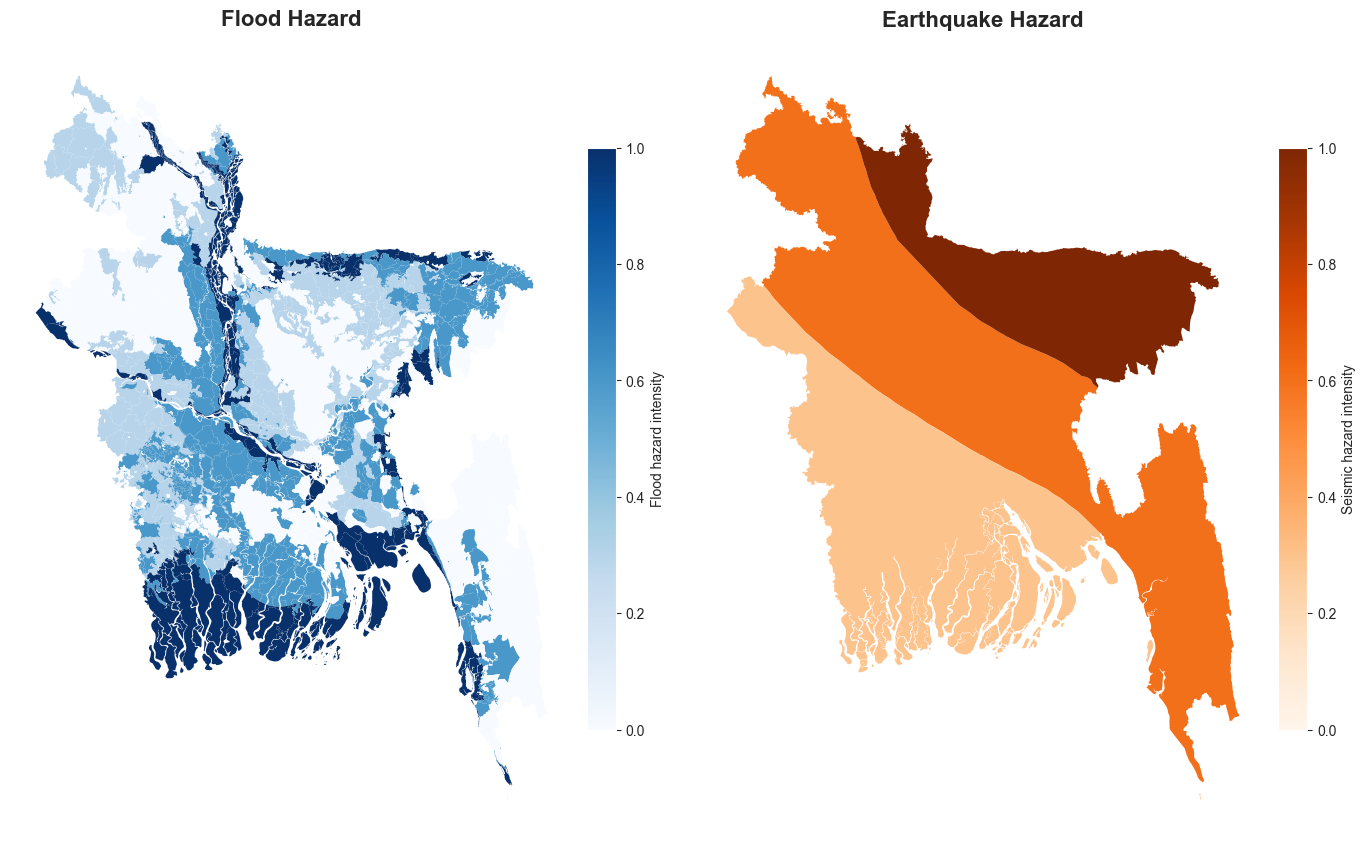

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10), facecolor='white')

# ── Flood hazard ─────────────────────────────────────────────────────────────
ax = axes[0]
gdf_flood.plot(
    column='flood_hazard_val',
    ax=ax,
    cmap='Blues',
    vmin=0, vmax=1,
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Flood hazard intensity', 'shrink': 0.6, 'pad': 0.02}
)
ax.set_title('Flood Hazard', fontsize=16, fontweight='bold', pad=10)
ax.set_axis_off()

# ── Earthquake hazard ─────────────────────────────────────────────────────────
ax = axes[1]
gdf_eq.plot(
    column='eq_hazard_val',
    ax=ax,
    cmap='Oranges',
    vmin=0, vmax=1,
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Seismic hazard intensity', 'shrink': 0.6, 'pad': 0.02}
)
ax.set_title('Earthquake Hazard', fontsize=16, fontweight='bold', pad=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('results data analysis/hazard_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## Spatial Join Vulnerability Data and Roads and Bridges

In [9]:
gdf_roads = gpd.sjoin(gdf_roads, gdf_flood[['geometry', 'flood_hazard_val', 'FLOODCAT']],
                      how='left', predicate='intersects')
if 'index_right' in gdf_roads.columns:
    gdf_roads = gdf_roads.drop(columns=['index_right'])

gdf_roads = gpd.sjoin(gdf_roads, gdf_eq[['geometry', 'eq_hazard_val', 'ZONE']],
                      how='left', predicate='intersects')

gdf_roads = gdf_roads.rename(columns={
    'flood_hazard_val': 'flood_hazard',
    'eq_hazard_val':    'eq_hazard',
    'ZONE':             'eq_zone',
    'FLOODCAT':         'flood_cat'
})

## Vulnerability Scoring

In [10]:
# 1. Map Internal Condition (A-D) to Scores 1-4
cond_to_score = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
gdf_roads['int_cond_score'] = gdf_roads['condition'].map(cond_to_score).fillna(1)

# 2. Assign Multipliers for Environmental Hazards
# Earthquake Seismic Multiplier (Zone I=1.0, II=1.5, III=2.0)
seismic_map = {'I': 1.0, 'II': 1.5, 'III': 2.0}
gdf_roads['seismic_mult'] = gdf_roads['eq_zone'].map(seismic_map).fillna(1.0)

# Flood Hazard Multiplier
# Using  FLOODCAT normalisation logic from the script: max severity = 2.0x
# Mapping flood_hazard (0-1) to a multiplier (1.0 to 2.0)
gdf_roads['flood_mult'] = 1.0 + gdf_roads['flood_hazard']

# 3. Calculate Final Integrated Vulnerability Score
# We take the maximum multiplier between Flood and EQ to find the dominant threat
gdf_roads['max_hazard_mult'] = gdf_roads[['seismic_mult', 'flood_mult']].max(axis=1)

# Final Formula: Internal Condition Score * Maximum Environmental Hazard
gdf_roads['vulnerability_score'] = gdf_roads['int_cond_score'] * gdf_roads['max_hazard_mult']

In [11]:
gdf_roads.columns

Index(['road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name', 'id',
       'length', 'type_simple', 'LRPName', 'length_bmms', 'condition',
       'name_bmms', 'model_type', 'geometry', 'link_no', 'heavy_truck',
       'medium_truck', 'small_truck', 'criticality_score', 'flood_hazard',
       'flood_cat', 'index_right', 'eq_hazard', 'eq_zone', 'int_cond_score',
       'seismic_mult', 'flood_mult', 'max_hazard_mult', 'vulnerability_score'],
      dtype='str')

In [12]:
# # Export enriched dataset with all scores
# gdf_roads.to_csv("../data/roads_after_dataanalysis.csv", index=False)
# print(f"Exported {len(gdf_roads)} rows with vulnerability and criticality scores.")

# Define explicit column order for consistent CSV output
output_cols = [
    'road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name', 'id',
    'length', 'type_simple', 'LRPName', 'length_bmms', 'condition',
    'name_bmms', 'model_type', 'geometry', 'link_no',
    'heavy_truck', 'medium_truck', 'small_truck', 'criticality_score',
    'flood_hazard', 'flood_cat', 'index_right', 'eq_hazard', 'eq_zone',
    'int_cond_score', 'seismic_mult', 'flood_mult', 'max_hazard_mult',
    'vulnerability_score'
]

# Only keep columns that actually exist (guards against missing optional cols)
output_cols = [c for c in output_cols if c in gdf_roads.columns]

# Export enriched dataset with all scores
gdf_roads[output_cols].to_csv("../data/new_data/roads_after_dataanalysis.csv", index=False)
print(f"Exported {len(gdf_roads)} rows with {len(output_cols)} columns.")
print("Columns:", output_cols)

Exported 19512 rows with 32 columns.
Columns: ['road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name', 'id', 'length', 'type_simple', 'LRPName', 'length_bmms', 'condition', 'name_bmms', 'model_type', 'geometry', 'link_no', 'heavy_truck', 'medium_truck', 'small_truck', 'criticality_score', 'flood_hazard', 'flood_cat', 'index_right', 'eq_hazard', 'eq_zone', 'int_cond_score', 'seismic_mult', 'flood_mult', 'max_hazard_mult', 'vulnerability_score']


---
# 04 Visualising Vulnerability and Criticality

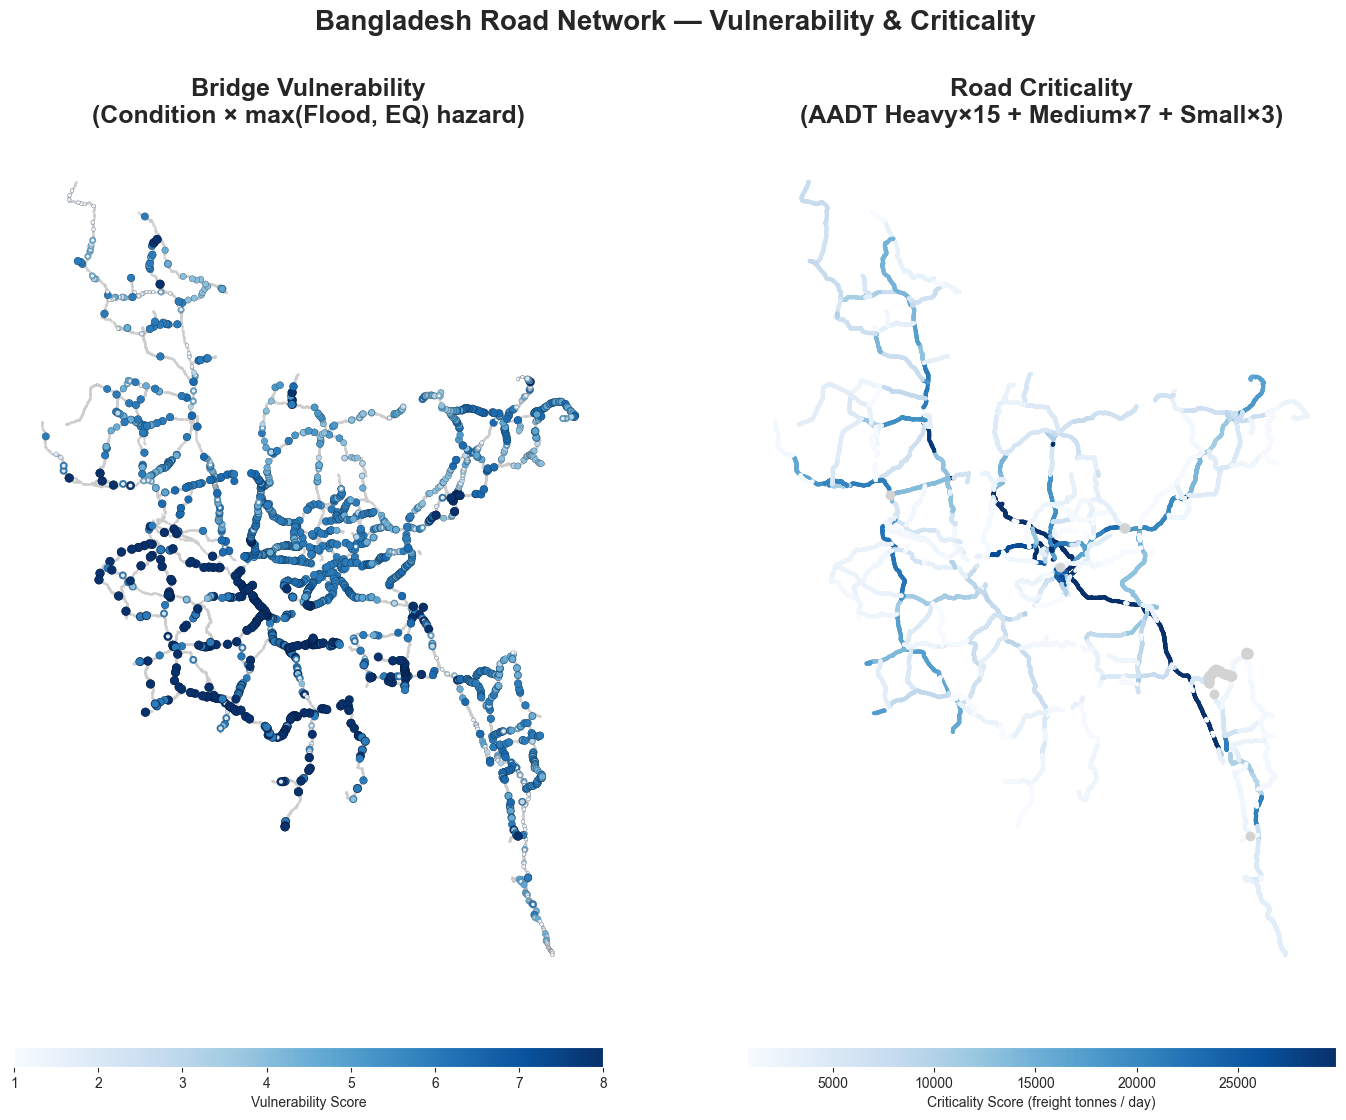

In [13]:
import matplotlib.pyplot as plt

links    = gdf_roads[gdf_roads['model_type'] == 'link']
bridges  = gdf_roads[gdf_roads['model_type'] == 'bridge']

fig, axes = plt.subplots(1, 2, figsize=(15, 12), facecolor='white')

# ── Links subplot helper ─────────────────────────────────────────────────────
LINK_KWARGS = dict(color='#cccccc', markersize=1, alpha=0.5, zorder=1)

# ── Left: Vulnerability ──────────────────────────────────────────────────────
ax = axes[0]
links.plot(ax=ax, **LINK_KWARGS)
bridges.plot(
    ax=ax,
    column='vulnerability_score',
    cmap='Blues',
    markersize=bridges['vulnerability_score'] * 5,
    edgecolor='black', linewidth=0.1,
    legend=True,
    legend_kwds={'label': "Vulnerability Score",
             'orientation': "horizontal",
             'pad': 0.05,
             'shrink': 0.8,
             'aspect': 30},
    zorder=2
)
ax.set_title("Bridge Vulnerability\n(Condition × max(Flood, EQ) hazard)",
             fontsize=18, fontweight='bold', pad=15)
ax.set_axis_off()

# ── Right: Criticality ───────────────────────────────────────────────────────
ax = axes[1]
vmin = gdf_roads['criticality_score'].quantile(0.05)
vmax = gdf_roads['criticality_score'].quantile(0.95)

gdf_roads.plot(
    ax=ax,
    column='criticality_score',
    cmap='Blues',
    markersize=4,
    vmin=vmin, vmax=vmax,
    legend=True,
    legend_kwds={'label': "Criticality Score (freight tonnes / day)",
             'orientation': "horizontal",
             'pad': 0.05,
             'shrink': 0.8,
             'aspect': 30},
    missing_kwds={'color': 'lightgrey'},
    zorder=1
)
ax.set_title("Road Criticality\n(AADT Heavy×15 + Medium×7 + Small×3)",
             fontsize=18, fontweight='bold', pad=15)

ax.set_axis_off()

plt.suptitle("Bangladesh Road Network — Vulnerability & Criticality",
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results data analysis/V vs C map.png', dpi=150, bbox_inches='tight')
plt.show()

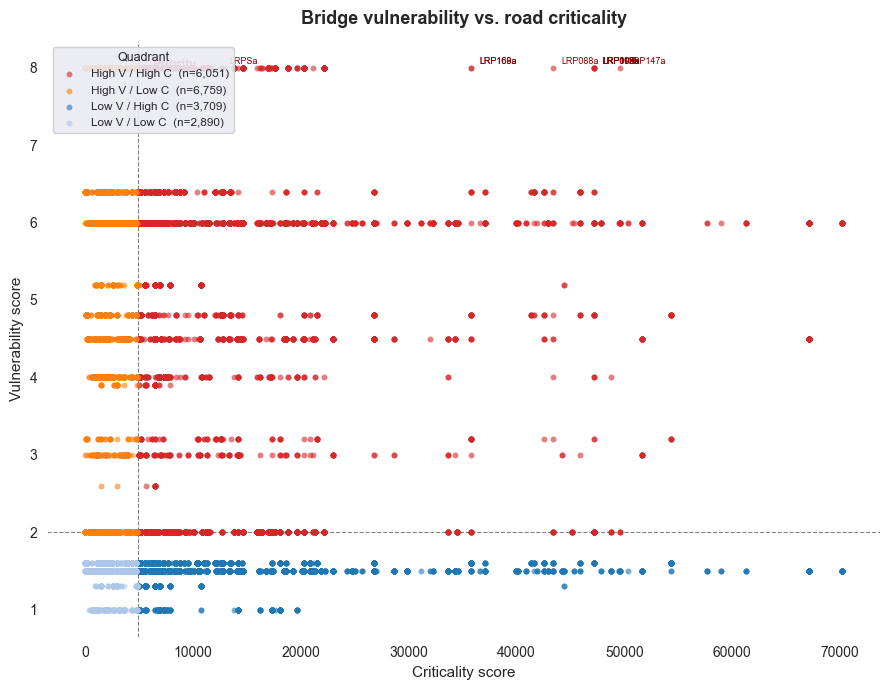

In [14]:
# ── 06 Quadrant scatter plot ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- use your merged bridge-level DataFrame here ---
df_plot = gdf_roads.dropna(subset=['vulnerability_score', 'criticality_score'])

v = df_plot['vulnerability_score']
c = df_plot['criticality_score']

# Thresholds (medians keep the quadrants balanced; swap to mean if preferred)
v_thresh = v.median()
c_thresh = c.median()

# Quadrant labels
def get_quadrant(row):
    if row['vulnerability_score'] >= v_thresh and row['criticality_score'] >= c_thresh:
        return 'High V / High C'
    elif row['vulnerability_score'] >= v_thresh:
        return 'High V / Low C'
    elif row['criticality_score'] >= c_thresh:
        return 'Low V / High C'
    else:
        return 'Low V / Low C'

df_plot = df_plot.copy()
df_plot['quadrant'] = df_plot.apply(get_quadrant, axis=1)

# Colours per quadrant
palette = {
    'High V / High C': '#d62728',   # red   — priority
    'High V / Low C':  '#ff7f0e',   # orange
    'Low V / High C':  '#1f77b4',   # blue
    'Low V / Low C':   '#aec7e8',   # light blue
}

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
ax.set_facecolor('white')

for quad, grp in df_plot.groupby('quadrant'):
    ax.scatter(
        grp['criticality_score'],
        grp['vulnerability_score'],
        c=palette[quad],
        s=18,
        alpha=0.6,
        linewidths=0,
        label=f'{quad}  (n={len(grp):,})',
        zorder=2
    )

# Quadrant dividers
ax.axhline(v_thresh, color='grey', lw=0.8, ls='--', zorder=1)
ax.axvline(c_thresh, color='grey', lw=0.8, ls='--', zorder=1)

# Quadrant labels in corners
offset = 0.02
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(c_thresh + (xmax - c_thresh) * offset, ymax - (ymax - ymin) * 0.03,
        'Priority', color='#d62728', fontsize=9, fontweight='bold', va='top')

# Top-10 priority bridges labelled
top10 = df_plot[df_plot['quadrant'] == 'High V / High C'].nlargest(10, 'vulnerability_score')
for _, row in top10.iterrows():
    ax.annotate(
        row['lrp'],
        xy=(row['criticality_score'], row['vulnerability_score']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=6.5, color='#8B0000'
    )

ax.set_xlabel('Criticality score', fontsize=11)
ax.set_ylabel('Vulnerability score', fontsize=11)
ax.set_title('Bridge vulnerability vs. road criticality', fontsize=13, fontweight='bold', pad=12)

legend = ax.legend(title='Quadrant', fontsize=8.5, title_fontsize=9,
                   framealpha=0.9, loc='upper left')

plt.tight_layout()
plt.savefig('results data analysis/quadrant_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 05 Data Analysis on Vulnerability

### Distribution Overview

C:\Users\Tijn\AppData\Local\Temp\ipykernel_36836\3798040203.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=order, patch_artist=True,


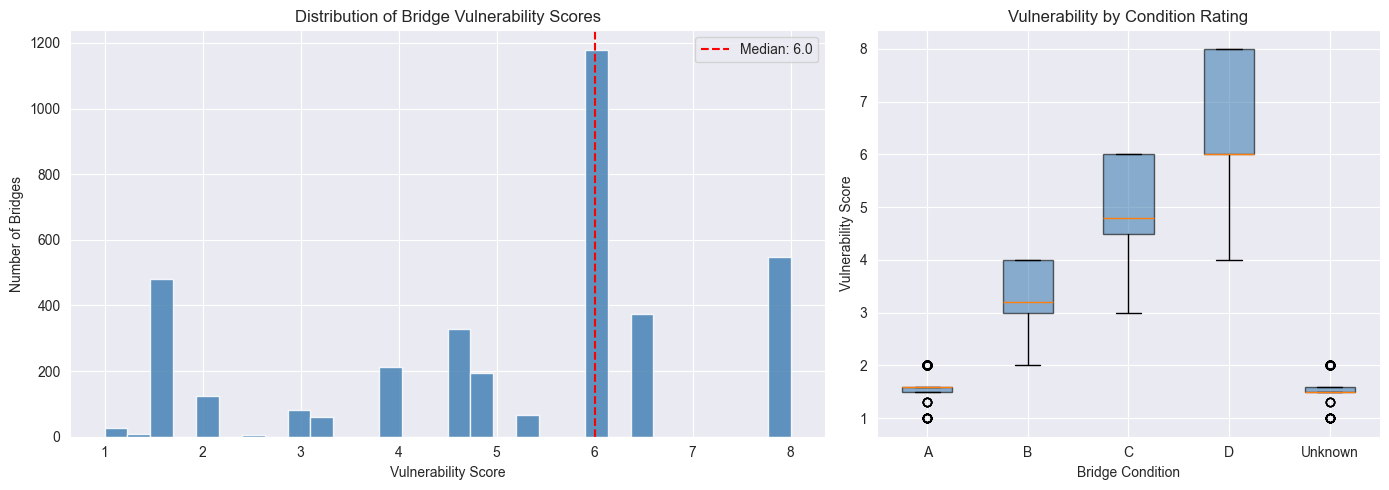

Bridges analysed : 3,689
Score range      : 1.0 – 8.0
Mean / Median    : 5.13 / 6.00


In [15]:
bridges = gdf_roads[gdf_roads['model_type'] == 'bridge'].copy()

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

# Left: histogram + KDE
ax1 = fig.add_subplot(gs[0])
ax1.hist(bridges['vulnerability_score'].dropna(), bins=30,
         color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel("Vulnerability Score")
ax1.set_ylabel("Number of Bridges")
ax1.set_title("Distribution of Bridge Vulnerability Scores")
ax1.axvline(bridges['vulnerability_score'].median(), color='red',
            linestyle='--', label=f"Median: {bridges['vulnerability_score'].median():.1f}")
ax1.legend()

# Right: boxplot per condition
ax2 = fig.add_subplot(gs[1])
order = ['A', 'B', 'C', 'D', 'Unknown']
data  = [bridges[bridges['condition'] == c]['vulnerability_score'].dropna()
         for c in order]
ax2.boxplot(data, labels=order, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax2.set_xlabel("Bridge Condition")
ax2.set_ylabel("Vulnerability Score")
ax2.set_title("Vulnerability by Condition Rating")

plt.tight_layout()
plt.show()

print(f"Bridges analysed : {len(bridges):,}")
print(f"Score range      : {bridges['vulnerability_score'].min():.1f} – "
      f"{bridges['vulnerability_score'].max():.1f}")
print(f"Mean / Median    : {bridges['vulnerability_score'].mean():.2f} / "
      f"{bridges['vulnerability_score'].median():.2f}")

The **histogram** shows how bridge vulnerability scores are distributed across the network. The histogram shows what the conceptualisation of the vulnerability score resulted in.

The **boxplot** shows how scores vary by condition rating. Since the formula multiplies condition score by a hazard multiplier, a condition D bridge can still score low if it sits in a low-hazard area and vice versa. Wide boxes indicate that location (hazard exposure) adds significant spread within each condition category.

## What drives Vulnerability: condition vs hazard

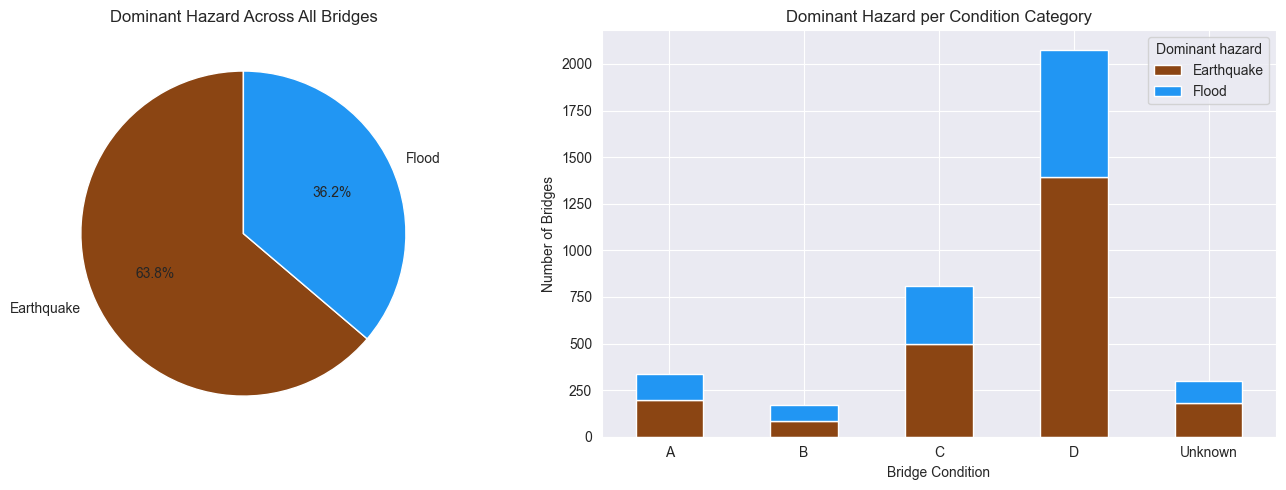

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bridges_temp = bridges.copy()
bridges_temp['dominant_hazard'] = bridges_temp.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake', axis=1
)

# Left: pie dominant hazard (keep)
counts = bridges_temp['dominant_hazard'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#8B4513', '#2196F3'], startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[0].set_title("Dominant Hazard Across All Bridges")

# Right: stacked bar — condition × dominant hazard
pivot = (bridges_temp
    .groupby(['condition', 'dominant_hazard'])
    .size()
    .unstack(fill_value=0)
    .reindex(['A', 'B', 'C', 'D', 'Unknown'])
)
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           color=['#8B4513', '#2196F3'], edgecolor='white')
axes[1].set_xlabel("Bridge Condition")
axes[1].set_ylabel("Number of Bridges")
axes[1].set_title("Dominant Hazard per Condition Category")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Dominant hazard")

plt.tight_layout()
plt.show()

## Most vulnerable bridges

In [17]:
bridges['dominant_hazard'] = bridges.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake',
    axis=1
)

bridges['lrp_base'] = bridges['lrp'].str.replace(r'[a-zA-Z]$', '', regex=True)

bridges_unique = (
    bridges
    .sort_values('vulnerability_score', ascending=False)
    .drop_duplicates(subset='lrp_base', keep='first')
)

max_vulnerability = bridges_unique['vulnerability_score'].max()
most_vulnerable_bridges = (
    bridges_unique[bridges_unique['vulnerability_score'] == max_vulnerability]
    [['road', 'lrp', 'lrp_base', 'name', 'condition', 'int_cond_score',
      'flood_mult', 'seismic_mult', 'max_hazard_mult',
      'dominant_hazard', 'vulnerability_score']]
    .sort_values(['road', 'lrp_base'])
    .reset_index(drop=True)
)

display(most_vulnerable_bridges)
print(f"Number of bridges with maximum vulnerability score ({max_vulnerability}): "
      f"{len(most_vulnerable_bridges)}")

,road,lrp,lrp_base,name,condition,int_cond_score,flood_mult,seismic_mult,max_hazard_mult,dominant_hazard,vulnerability_score
0,N1,LRP095a,LRP095,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
1,N1,LRP099b,LRP099,Bridge end,D,4.0,2.0,1.5,2.0,Flood,8.0
2,N1,LRP105a,LRP105,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
3,N1,LRP108a,LRP108,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
4,N1,LRP113b,LRP113,Bridge end,D,4.0,2.0,1.5,2.0,Flood,8.0
...,...,...,...,...,...,...,...,...,...,...,...
78,R880,LRP047c,LRP047,Bridge Start,D,4.0,2.0,2.0,2.0,Flood,8.0
79,R881,LRP035a,LRP035,R.C.C Bridge start,D,4.0,2.0,2.0,2.0,Flood,8.0
80,R881,LRP038b,LRP038,Baily Bridge end,D,4.0,2.0,2.0,2.0,Flood,8.0
81,R881,LRP039b,LRP039,R.C.C Bridge end,D,4.0,2.0,2.0,2.0,Flood,8.0


Number of bridges with maximum vulnerability score (8.0): 83


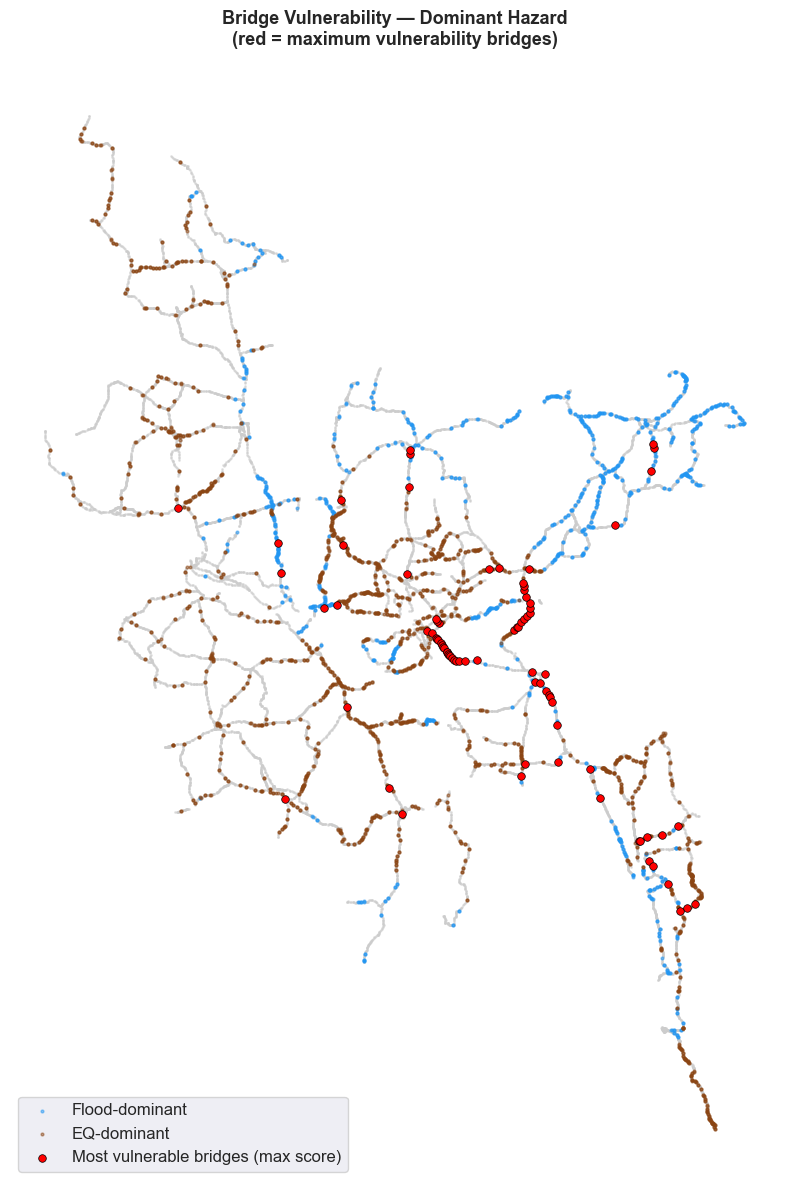

In [18]:
# Map: all bridges flood/EQ colored, most vulnerable highlighted

links = gdf_roads[gdf_roads['model_type'] == 'link']
bridges_map = bridges.copy()
bridges_map['dominant_hazard'] = bridges_map.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake',
    axis=1
)

bridges_map['lrp_base'] = bridges_map['lrp'].str.replace(r'[a-zA-Z]$', '', regex=True)

# splits per hazard
flood_bridges = bridges_map[bridges_map['dominant_hazard'] == 'Flood']
eq_bridges    = bridges_map[bridges_map['dominant_hazard'] == 'Earthquake']

# select bridges
most_vulnerable_geo = bridges_map[
    bridges_map['lrp_base'].isin(most_vulnerable_bridges['lrp_base'])
].drop_duplicates(subset='lrp_base')

# make plot
fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')

links.plot(ax=ax, color='#cccccc', markersize=1, alpha=0.5, zorder=1)

flood_bridges.plot(
    ax=ax, color='#2196F3', markersize=4,
    alpha=0.5, label='Flood-dominant', zorder=2
)

eq_bridges.plot(
    ax=ax, color='#8B4513', markersize=4,
    alpha=0.5, label='EQ-dominant', zorder=2
)

most_vulnerable_geo.plot(
    ax=ax, color='red', markersize=30,
    edgecolor='black', linewidth=0.5,
    label='Most vulnerable bridges (max score)', zorder=3
)

ax.set_title(
    "Bridge Vulnerability — Dominant Hazard\n(red = maximum vulnerability bridges)",
    fontsize=13, fontweight='bold', pad=15
)

ax.legend(loc='lower left',  fontsize=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Most Vulnerable Roads

In [19]:
road_length = (
    gdf_roads
    .groupby('road')['length']
    .sum()
    .reset_index(name='total_length_m')
)

road_vuln = (
    bridges
    .groupby('road')
    .agg(
        total_vulnerability = ('vulnerability_score', 'sum'),
        mean_vulnerability  = ('vulnerability_score', 'mean'),
        n_bridges           = ('vulnerability_score', 'count')
    )
    .reset_index()
)

road_analysis = road_vuln.merge(road_length, on='road', how='left')
road_analysis['length_km'] = road_analysis['total_length_m'] / 1000

# vulnerability per km (voor referentie, maar niet hoofdmetric)
road_analysis['vuln_per_km'] = (
    road_analysis['total_vulnerability'] / road_analysis['length_km']
)

road_analysis['vuln_hybrid'] = (
    road_analysis['mean_vulnerability'] *
    np.log1p(road_analysis['length_km'])   # log(1 + length)
)

road_analysis['bridges_per_km'] = (
    road_analysis['n_bridges'] / road_analysis['length_km']
)

top10_vulnerable_roads = (
    road_analysis
    .sort_values('mean_vulnerability', ascending=False)
    .head(10)
    [['road', 'mean_vulnerability', 'n_bridges', 'length_km', 'bridges_per_km']]
    .reset_index(drop=True)
)
display(top10_vulnerable_roads)

,road,mean_vulnerability,n_bridges,length_km,bridges_per_km
0,N101,8.0,2,5.834159,0.342809
1,N120,8.0,2,20.614528,0.097019
2,N803,8.0,4,5.534126,0.722788
3,N809,8.0,11,64.559439,0.170386
4,N603,8.0,4,20.419353,0.195893
5,N703,8.0,2,3.133419,0.638280
6,N604,8.0,2,7.663425,0.260980
7,R749,8.0,2,27.781159,0.071991
8,R713,8.0,2,5.134709,0.389506
9,R747,8.0,7,41.689122,0.167910


C:\Users\Tijn\AppData\Local\Temp\ipykernel_36836\582198470.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roads = plt.cm.get_cmap('YlOrRd', 10)


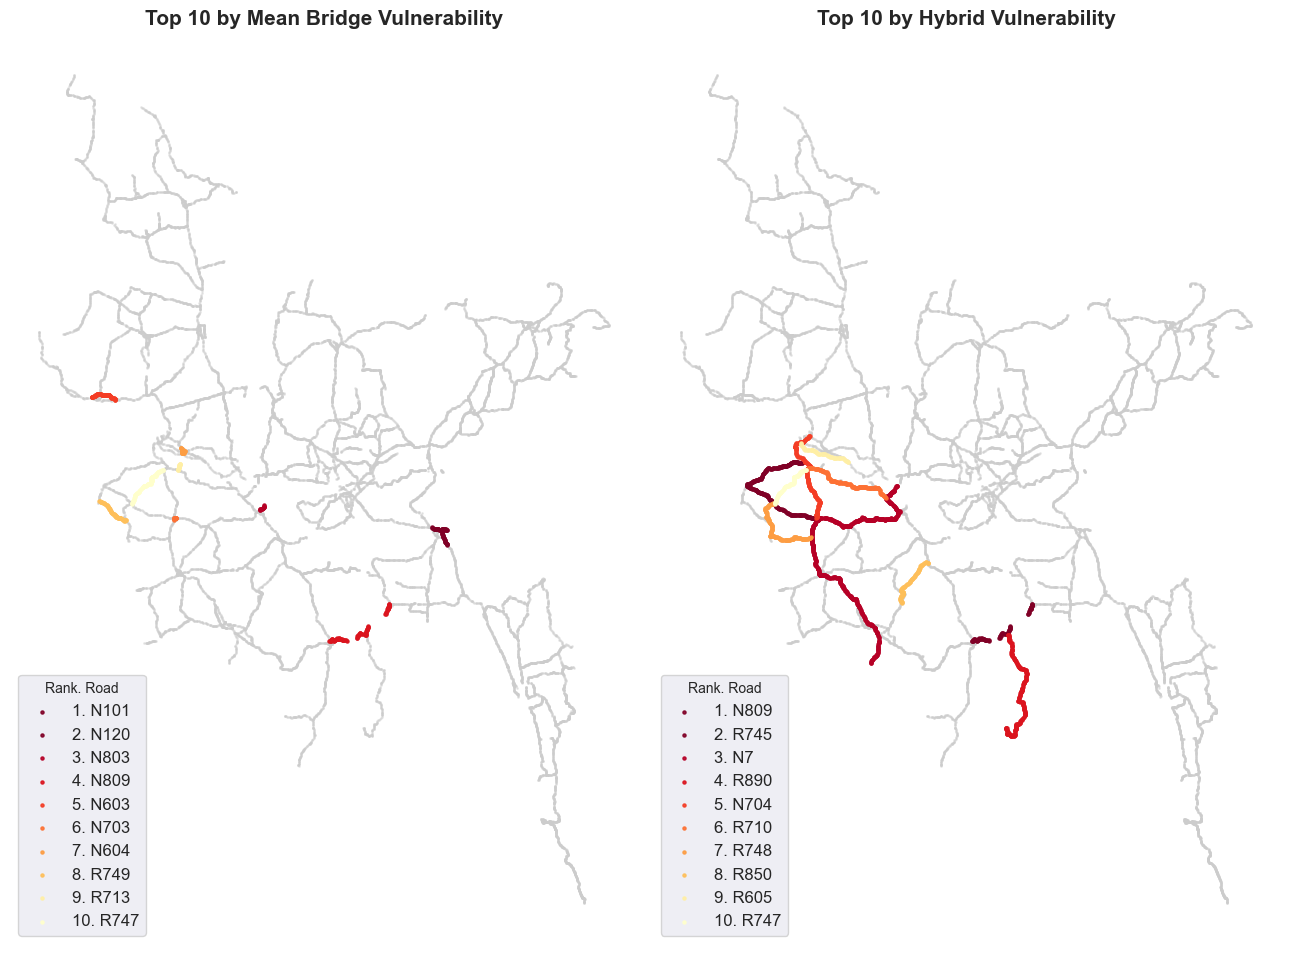

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 10), facecolor='white')

top10_mean   = road_analysis.sort_values('mean_vulnerability',  ascending=False).head(10)
top10_hybrid = road_analysis.sort_values('vuln_hybrid',         ascending=False).head(10)

top10_mean_names   = top10_mean['road'].tolist()
top10_hybrid_names = top10_hybrid['road'].tolist()

cmap_roads = plt.cm.get_cmap('YlOrRd', 10)

# ── Left: top 10 by mean vulnerability ───────────────────────────────────────
ax = axes[0]
other = gdf_roads[~gdf_roads['road'].isin(top10_mean_names)]
other.plot(ax=ax, color='#cccccc', markersize=1, alpha=0.4, zorder=1)
for i, road in enumerate(top10_mean_names):
    gdf_roads[gdf_roads['road'] == road].plot(
        ax=ax, color=cmap_roads(1 - i / 10),
        markersize=5, alpha=0.9, zorder=2, label=f"{i+1}. {road}"
    )
ax.set_title("Top 10 by Mean Bridge Vulnerability",
             fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=12, title="Rank. Road")
ax.set_axis_off()

# ── Right: top 10 by hybrid score ────────────────────────────────────────────
ax = axes[1]
other = gdf_roads[~gdf_roads['road'].isin(top10_hybrid_names)]
other.plot(ax=ax, color='#cccccc', markersize=1, alpha=0.4, zorder=1)
for i, road in enumerate(top10_hybrid_names):
    gdf_roads[gdf_roads['road'] == road].plot(
        ax=ax, color=cmap_roads(1 - i / 10),
        markersize=5, alpha=0.9, zorder=2, label=f"{i+1}. {road}"
    )
ax.set_title("Top 10 by Hybrid Vulnerability",
             fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=12, title="Rank. Road")
ax.set_axis_off()

plt.tight_layout()
plt.show()

---
# 06 Data Analysis on Criticality

## Most Critical Bridges
* Bridge criticality is derived from the freight flow on the road segment (link) to which each bridge belongs. Since multiple records may exist for a single physical bridge (e.g. start/end points), bridges are first aggregated using a base identifier (lrp_base), which removes suffixes such as 'a' and 'b'.
* For each bridge (lrp_base), the maximum criticality score is selected, representing the highest freight exposure at that crossing. This ensures that each physical bridge is counted only once and reflects its most critical loading condition.
* The top 10 most critical bridges are then identified by ranking these values.

In [21]:
bridges['lrp_base'] = bridges['lrp'].str.replace(r'[a-zA-Z]$', '', regex=True)

critical_bridges_base = (
    bridges
    .dropna(subset=['criticality_score'])
    .groupby(['road', 'lrp_base'])
    .agg(
        criticality_score=('criticality_score', 'max'),  # worst-case exposure
        name=('name', 'first')
    )
    .reset_index()
    .sort_values('criticality_score', ascending=False)
)

top10_critical_bridges = critical_bridges_base.head(10)

display(top10_critical_bridges)

,road,lrp_base,criticality_score,name
390,N4,LRP004,70191.0,Bridge Start
389,N4,LRP003,70191.0,Bridge start
391,N4,LRP005,70191.0,Bridge Start
399,N4,LRP038,67081.0,Bridge start
396,N4,LRP024,67081.0,Bridge start
394,N4,LRP022,67081.0,Bridge Start
395,N4,LRP023,67081.0,Bridge Start
397,N4,LRP029,67081.0,Bridge start
398,N4,LRP035,67081.0,Bridge start
400,N4,LRP040,67081.0,Bridge start


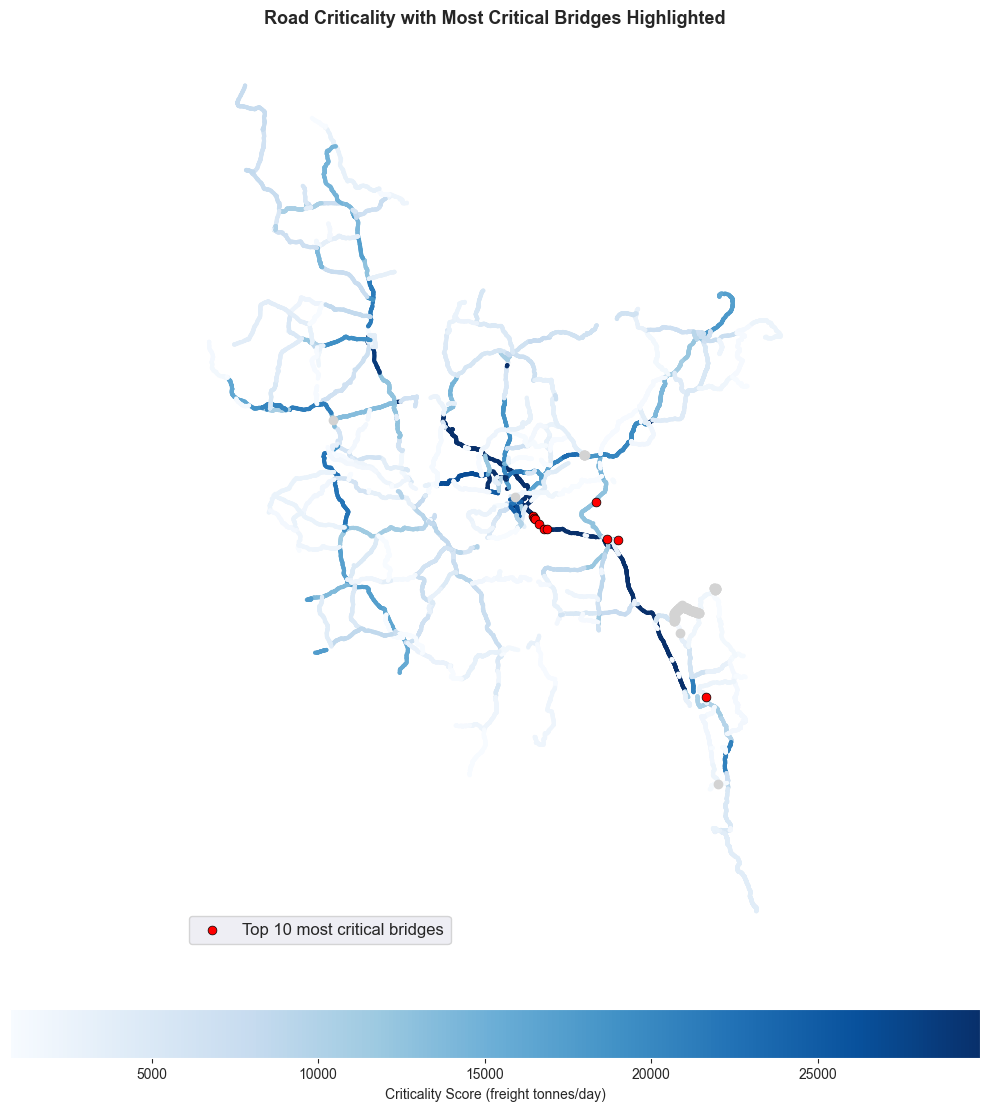

In [22]:
bridges_map = bridges.copy()
bridges_map['lrp_base'] = bridges_map['lrp'].str.replace(r'[a-zA-Z]$', '', regex=True)

# select most critical bridges (unique)
most_critical_geo = bridges_map[
    bridges_map['lrp_base'].isin(top10_critical_bridges['lrp_base'])
].drop_duplicates(subset='lrp_base')

fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')

vmin = gdf_roads['criticality_score'].quantile(0.05)
vmax = gdf_roads['criticality_score'].quantile(0.95)

gdf_roads.plot(
    ax=ax,
    column='criticality_score',
    cmap='Blues',
    markersize=4,
    vmin=vmin, vmax=vmax,
    legend=True,
    legend_kwds={
        'label': "Criticality Score (freight tonnes/day)",
        'orientation': "horizontal", 'pad': 0.05
    },
    missing_kwds={'color': 'lightgrey'},
    zorder=1
)

most_critical_geo.plot(
    ax=ax,
    color='red',
    markersize=40,
    edgecolor='black',
    linewidth=0.5,
    label='Top 10 most critical bridges',
    zorder=3
)

ax.set_title(
    "Road Criticality with Most Critical Bridges Highlighted",
    fontsize=13, fontweight='bold', pad=15
)

ax.legend(loc='lower left', fontsize=12 )
ax.set_axis_off()

plt.tight_layout()
plt.show()

## Most Critical Roads

* Road criticality is determined by aggregating freight flows across all links belonging to a road. Since criticality represents freight volume, it is assumed to be additive across segments.
* To avoid double counting, aggregation is first performed at the link level (link_no), ensuring each segment contributes only once. These values are then summed per road to obtain total criticality.
* The top 10 most critical roads are identified based on total freight flow, representing the most economically important corridors in the network.

In [23]:
road_criticality = (
    gdf_roads
    .dropna(subset=['criticality_score'])
    .groupby(['road', 'link_no'])
    .agg(link_criticality=('criticality_score', 'first'))
    .reset_index()
    .groupby('road')
    .agg(
        total_criticality=('link_criticality', 'sum'),
        mean_criticality=('link_criticality', 'mean'),
        n_links=('link_criticality', 'count')
    )
    .reset_index()
    .sort_values('total_criticality', ascending=False)
)

top10_critical_roads = road_criticality.head(10)
display(top10_critical_roads)

,road,total_criticality,mean_criticality,n_links
0,N1,1879604.0,27240.637681,69
39,N5,1029767.0,15602.530303,66
30,N4,710700.0,41805.882353,17
18,N2,580808.0,20027.862069,29
64,N7,463418.0,13629.941176,34
26,N3,315023.0,17501.277778,18
59,N6,298465.0,10659.464286,28
27,N302,247989.0,49597.800000,5
5,N105,241538.0,34505.428571,7
68,N704,237315.0,21574.090909,11


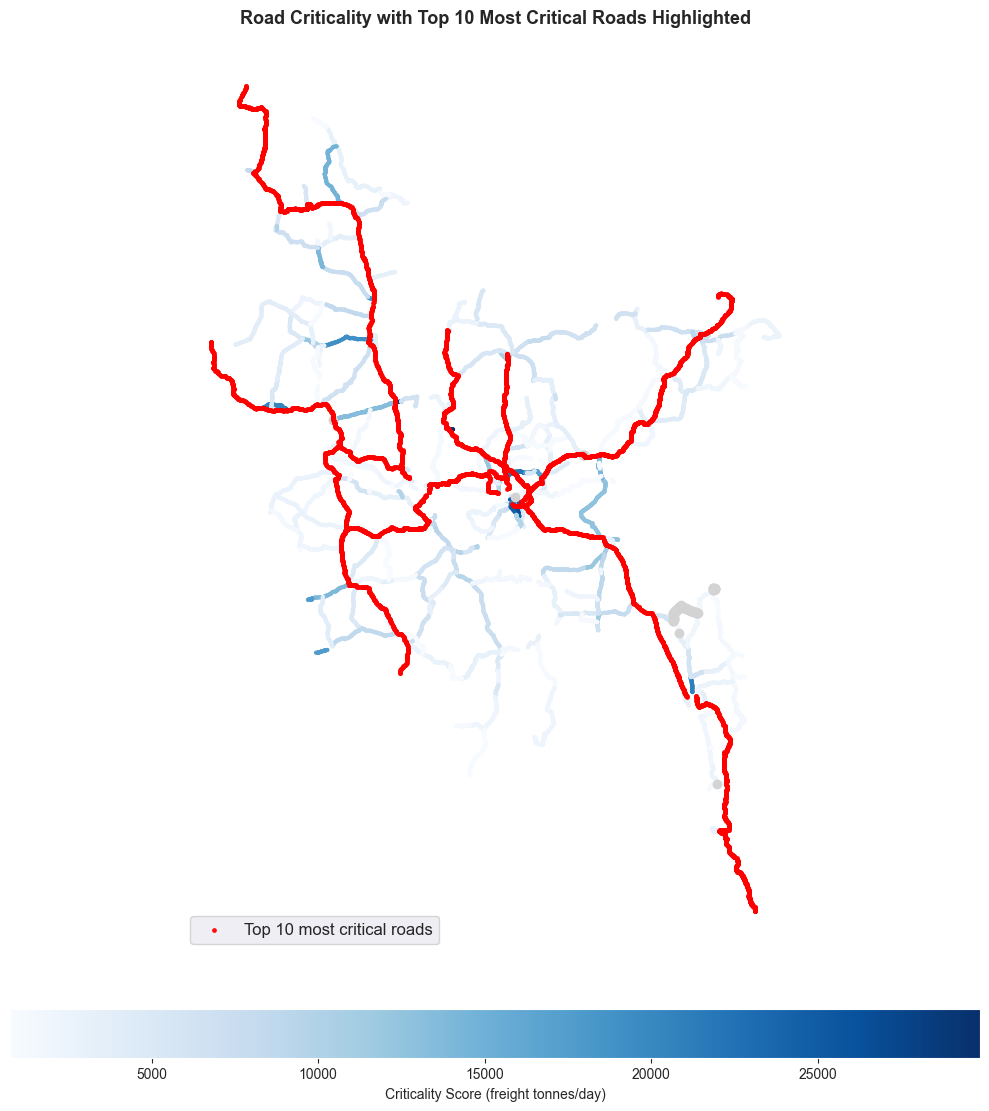

In [24]:
top_roads = top10_critical_roads['road'].tolist()

highlight = gdf_roads[gdf_roads['road'].isin(top_roads)]
other     = gdf_roads[~gdf_roads['road'].isin(top_roads)]

fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')

vmin = gdf_roads['criticality_score'].quantile(0.05)
vmax = gdf_roads['criticality_score'].quantile(0.95)

other.plot(
    ax=ax,
    column='criticality_score',
    cmap='Blues',
    markersize=4,
    vmin=vmin, vmax=vmax,
    legend=True,
    legend_kwds={
        'label': "Criticality Score (freight tonnes/day)",
        'orientation': "horizontal", 'pad': 0.05
    },
    missing_kwds={'color': 'lightgrey'},
    zorder=1
)

highlight.plot(
    ax=ax,
    color='red',
    markersize=6,
    alpha=0.9,
    label='Top 10 most critical roads',
    zorder=3
)

# layout
ax.set_title(
    "Road Criticality with Top 10 Most Critical Roads Highlighted",
    fontsize=13, fontweight='bold', pad=15
)

ax.legend(loc='lower left', fontsize=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

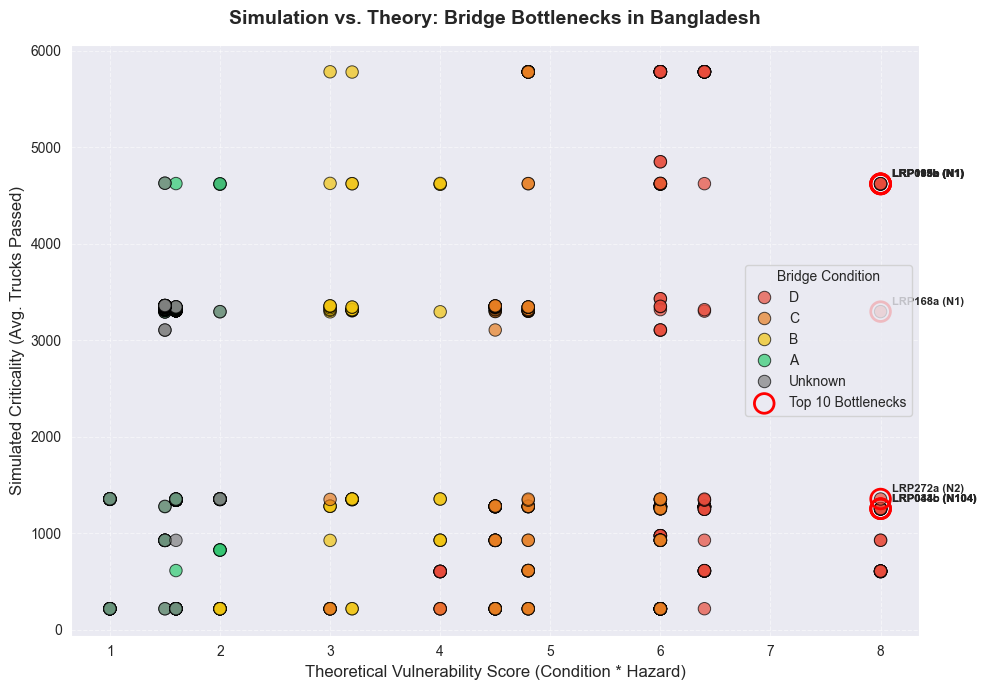


TOP 10 BOTTLENECKS:


,road,lrp,name,condition,vulnerability_score,simulated_trucks
248,N1,LRP113b,Bridge end,D,8.0,4622.0
233,N1,LRP108a,Bridge start,D,8.0,4621.6
227,N1,LRP105a,Bridge start,D,8.0,4620.1
214,N1,LRP099b,Bridge end,D,8.0,4618.8
206,N1,LRP095a,Bridge start,D,8.0,4616.8
365,N1,LRP168a,Bridge start,D,8.0,3296.0
3189,N2,LRP272a,Bridge start,D,8.0,1353.9
1685,N104,LRP043c,Bridge start,D,8.0,1253.6
1690,N104,LRP044c,Bridge start,D,8.0,1253.6
1657,N104,LRP034b,Bridge start,D,8.0,1252.8


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load theory data
theorie_path = '../data/new_data/roads_after_dataanalysis.csv'
gdf_roads = pd.read_csv(theorie_path)

# load simulation data
sim_path = '../model/results simulation/bridges_S0.csv'

try:
    df_sim = pd.read_csv(sim_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Error: Could not find {sim_path}.")

# calculate average amount of trucks
sim_agg = df_sim.groupby('bridge_id')['trucks_passed'].mean().reset_index()
sim_agg.rename(columns={'trucks_passed': 'simulated_trucks'}, inplace=True)

# merging
gdf_roads = gdf_roads.merge(sim_agg, left_on='id', right_on='bridge_id', how='left')

# filtering
final_bridges = gdf_roads[gdf_roads['model_type'] == 'bridge'].copy()

# compare
plt.figure(figsize=(10, 7), facecolor='white')

sns.scatterplot(
    data=final_bridges,
    x='vulnerability_score',
    y='simulated_trucks',
    hue='condition',
    palette={'A': '#2ecc71', 'B': '#f1c40f', 'C': '#e67e22', 'D': '#e74c3c', 'Unknown': 'grey'},
    s=80, alpha=0.7, edgecolor='black'
)

# top 10 bottlenecks
top_bottlenecks = final_bridges.sort_values(
    by=['vulnerability_score', 'simulated_trucks'],
    ascending=[False, False]
).head(10)

plt.scatter(
    top_bottlenecks['vulnerability_score'],
    top_bottlenecks['simulated_trucks'],
    color='none', edgecolor='red', linewidth=2, s=200, label='Top 10 Bottlenecks'
)

for _, row in top_bottlenecks.iterrows():
    plt.annotate(
        f"{row['lrp']} ({row['road']})",
        (row['vulnerability_score'], row['simulated_trucks']),
        xytext=(8, 5), textcoords='offset points', fontsize=8, fontweight='bold'
    )

plt.title('Simulation vs. Theory: Bridge Bottlenecks in Bangladesh', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Theoretical Vulnerability Score (Condition * Hazard)', fontsize=12)
plt.ylabel('Simulated Criticality (Avg. Trucks Passed)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Bridge Condition')

plt.tight_layout()
plt.savefig('simulation_vs_theory.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTOP 10 BOTTLENECKS:")
display(top_bottlenecks[['road', 'lrp', 'name', 'condition', 'vulnerability_score', 'simulated_trucks']])

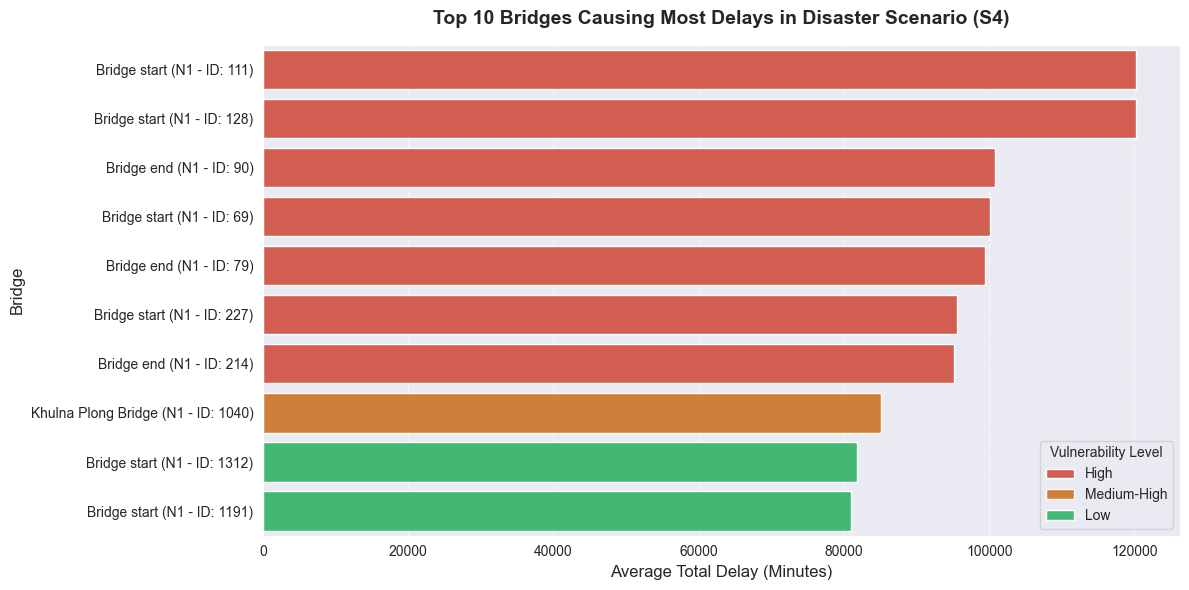


TOP 10 DELAYS (S4):


,bridge_id,road,bridge_name,vuln_level,avg_breakdowns,avg_delay_min,avg_trucks
40,111,N1,Bridge start,High,0.6,120261.3,5368.8
44,128,N1,Bridge start,High,0.6,120178.4,5367.0
33,90,N1,Bridge end,High,0.5,100805.6,5371.9
20,69,N1,Bridge start,High,0.5,100086.7,5375.5
27,79,N1,Bridge end,High,0.5,99419.9,5373.6
60,227,N1,Bridge start,High,0.6,95551.4,4243.8
57,214,N1,Bridge end,High,0.6,95176.3,4235.4
225,1040,N1,Khulna Plong Bridge,Medium-High,0.4,85095.5,3119.9
305,1312,N1,Bridge start,Low,0.2,81846.4,3186.5
269,1191,N1,Bridge start,Low,0.2,81019.3,3156.0


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load simulation data for S4
s4_path = '../model/results simulation/bridges_S4.csv'

try:
    df_s4 = pd.read_csv(s4_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Error: Could not find {s4_path}.")

# calculate average delay and breakdowns
delay_agg = df_s4.groupby(['bridge_id', 'bridge_name', 'road', 'condition', 'vulnerability_score', 'vuln_level']).agg(
    avg_delay_min=('total_delay_min', 'mean'),
    avg_breakdowns=('breakdown_count', 'mean'),
    avg_trucks=('trucks_passed', 'mean')
).reset_index()

# top 10 bottlenecks by delay
top_delays = delay_agg.sort_values(by='avg_delay_min', ascending=False).head(10)

# compare
plt.figure(figsize=(12, 6), facecolor='white')

# create labels for y-axis WITH ID to prevent merging identical names
top_delays['label'] = top_delays['bridge_name'] + ' (' + top_delays['road'] + ' - ID: ' + top_delays['bridge_id'].astype(str) + ')'

sns.barplot(
    data=top_delays,
    x='avg_delay_min',
    y='label',
    hue='vuln_level',
    dodge=False,
    palette={'High': '#e74c3c', 'Medium-High': '#e67e22', 'Medium-Low': '#f1c40f', 'Low': '#2ecc71'}
)

plt.title('Top 10 Bridges Causing Most Delays in Disaster Scenario (S4)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Total Delay (Minutes)', fontsize=12)
plt.ylabel('Bridge', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Vulnerability Level', loc='lower right')

plt.tight_layout()
plt.savefig('top_10_delays_S4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTOP 10 DELAYS (S4):")
display(top_delays[['bridge_id', 'road', 'bridge_name', 'vuln_level', 'avg_breakdowns', 'avg_delay_min', 'avg_trucks']])